In [2]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!
import pickle
import datetime
from logic import gwyfile as gwy
import numpy as np
from scipy.signal import find_peaks

In [3]:
filebeginning = '20250210-1644-37_Hecho-alt-phased_A-F17-26_NbTiN_Paris_S1_3K_70mT_Bnv_OOC_pulsed_measurement' #here the beginning of the filename, including the date and sample name, is needed
filebeginning_1 = '20250210-1657-57_Hecho-alt-phased_A-F17-26_NbTiN_Paris_S1_3K_70mT_Bnv_IC_pulsed_measurement' #here the beginning of the filename, including the date and sample name, is needed

file_year = filebeginning[0:4]
file_month = filebeginning[4:6]
file_day = filebeginning[6:8]
path = 'G:\\Data\\Qudi_Data\\'+file_year+'\\'+file_month+'\\'+file_year+file_month+file_day+'\\PulsedMeasurement\\'
filepath = path + filebeginning + '.dat'

file_year_1 = filebeginning_1[0:4]
file_month_1 = filebeginning_1[4:6]
file_day_1 = filebeginning_1[6:8]
path_1 = 'G:\\Data\\Qudi_Data\\'+file_year_1+'\\'+file_month_1+'\\'+file_year_1+file_month_1+file_day_1+'\\PulsedMeasurement\\'
filepath_1 = path_1 + filebeginning_1 + '.dat'

filepath_com = [filepath, filepath_1]

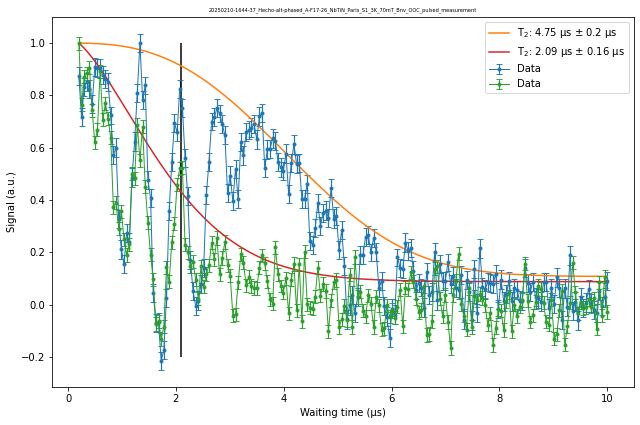

In [5]:
plt.rcParams.update({'font.size': 10})
fig = plt.figure(figsize = (9, 6))

ax_HE = fig.add_subplot()

ax_HE.set_xlabel('Waiting time (µs)')
ax_HE.set_ylabel('Signal (a.u.)')

ax_HE.title.set_text(filebeginning)
ax_HE.title.set_size(5)

plot_option = 3 #1 = Signal1, 2 = Signal2, 3 = delta of signals
data_raw_com = []
data_raw_err_com = []

for idx, paths in enumerate(filepath_com):
    data_raw = np.loadtxt(paths).T
    var_list = data_raw[0]

    err = None

    var_list_more = np.linspace(var_list[0],var_list[-1],1000)

    #Choose what to plot
    if plot_option == 3:
        data = data_raw[1] - data_raw[2]
        shift = (data_raw.shape[0]-1)//2
        err1 = abs(data_raw[1+shift])
        err2 = abs(data_raw[2+shift])
        err = err1+err2
    else:
        data = data_raw[plot_option]
        shift = (data_raw.shape[0]-1)//2
        err = data_raw[plot_option+shift]

    peaks, _ = find_peaks(data, prominence=(0.02, None))#, distance=20)
    peaks = np.insert(peaks, 0, 0, axis=0)
    fit_peaks = fitlogic.make_decayexponentialstretched_fit(var_list[peaks],data[peaks],estimator=fitlogic.estimate_decayexponentialstretched)
    lm_peaks,_ = fitlogic.make_decayexponentialstretched_model()
    temp = lm_peaks.eval(fit_peaks.params, x=var_list_more)
    t2s = fit_peaks.params['lifetime']
    t2s_err = fit_peaks.params['lifetime'].stderr

    ax_HE.errorbar(x=var_list*1e6, y=data/np.max(data),
                             yerr=err, fmt='-o',
                             capsize=3, capthick=0.9,
                            elinewidth=1.2, markersize=3, linewidth=1.0, label="Data")
    leg = f"T$_2$: {round(fit_peaks.params['lifetime']*1e6,2)} µs $\pm$ {round(fit_peaks.params['lifetime'].stderr*1e6,2)} µs"
    ax_HE.plot(var_list_more*1e6, temp/np.max(temp),'-', linewidth=1.5, label=leg)

ax_HE.legend()

ax_HE.vlines(2.1,-0.2,1,'k')

plt.tight_layout()

# with open(path + filebeginning+'_envelope_fit.png', 'wb') as f:
#     plt.savefig(f,format='png')

plt.show()